# S2BIOPHYS Analysis - GEE Python API

GEE Python API examples for accessing annual S2BIOPHYS maps stored in Earth-Engine.

Project repository:
    https://github.com/speckerf/world-reforestation-monitor

Citation:
    Specker, F., Schweiger, A. K., Féret, J.-B., et al. (2026).
    Advancing Ecosystem Monitoring with Global High-Resolution Maps of
    Vegetation Biophysical Properties. Research Square, Version 2 [preprint].
    https://doi.org/10.21203/rs.3.rs-6343364/v2

Required packages:
    earthengine-api, geemap, pandas, matplotlib, IPython

Last updated: September 2026


## Notes

S2BIOPHYS annual products are stored in GEE as [MGRS tiles](https://hls.gsfc.nasa.gov/wp-content/uploads/2023/09/MGRS_GZD-1-1.png), each each tile's native Sentinel-2 UTM projection. Retaining the native projection avoids additional reprojection before users transform the data to their desired projection. Analyses spanning multiple MGRS tiles require the products to be mosaicked. The functions below provides access to the products as a singlemosaic; GEE reprojects the data on the fly according to the projection and scale requested by the analysis. 

- At 20 m resolution, S2BIOPHYS annual products contain two bands: mean retrieval and total uncertainty (stdDev).
- At 100 m resolution, S2BIOPHYS annual products contain three additional bands: count, stdDev_within, stdDev_across

Individual images follow this naming convention: 

- Example: fcover_rtm-mlp-v02_mean-std-n_100m_s_20190101_20191231_T01K_epsg-32701_v03
- Template: {variable}_rtm-mlp-v02_mean-std-n_{resolution}_s_{year}0101_{year}1231_T{mgrs_tile}_{crs}_v03

**Masking uncertain retrievals.** Three masking options are enabled by default to exclude potentially unreliable S2BIOPHYS retrievals:
1. High total uncertainty: Total uncertainty combines retrieval uncertainty within individual acquisitions (`stdDev_within`) and variation among retrievals from different acquisitions (`stdDev_across`).
2. High extrapolation score: Retrieval performance declines as spectral distance from the simulated training domain increases. We therefore mask retrievals beyond the indicative distance threshold identified in Figure S9 (see manuscript).
3. Insufficient Sentinel-2 observations: Annual products are derived from growing-season observations retained after image-quality and cloud filtering. We recommend using annual retrievals only when they are based on at least two valid S2 observations. 


## Setup

Install or update the required packages once if needed:

```python
%pip install --upgrade earthengine-api geemap pandas matplotlib
```

Restart the kernel after changing package versions.

In [1]:
from __future__ import annotations

from copy import deepcopy
from typing import Any

import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ee.Initialize()

## Configuration

In [2]:
config: dict[str, Any] = {
    "years": ["2019", "2020", "2021", "2022", "2023", "2024", "2025"],
    "traits": ["laie", "fapar", "fcover"],
    # "20m" or "100m"
    "resolution": "20m",
    # At 20 m, these bands are linked from the 100 m products.
    "link_from_resolution": "100m",
    "link_only_bands": ["count", "stdDev_across", "stdDev_within"],
    "scaling_factors": {
        "fapar": 10_000,
        "fcover": 10_000,
        "laie": 1_000,
    },
    # Mask pixels with high total retrieval uncertainty.
    "std_mask": True,
    "std_mask_thresholds": {
        "fapar": 5_000,
        "fcover": 5_000,
        "laie": 1_500,
    },
    # Mask pixels with a high extrapolation score (distance to training LUT).
    "extrapolation_mask": True,
    "extrapolation_mask_threshold": 3.5,
    # Retain pixels with at least this many observations.
    "min_observation_mask": True,
    "min_observation_number": 2,
    # Output band order.
    "output_bands": [
        "mean",
        "stdDev",
        "stdDev_across",
        "stdDev_within",
        "count",
    ],
    # Asset paths.
    "asset_root": "projects/ee-speckerfelix/assets/open-earth/",
    "knn_distance_collection": (
        "projects/ee-speckerfelix/assets/open-earth/knn-distance_all-traits_100m"
    ),
    # Product version.
    "version": "v03",
}

In [3]:
vis: dict[str, Any] = {
    "palettes": {
        "fcover_mean": [
            "#f7fcf5",
            "#c7e9c0",
            "#74c476",
            "#238b45",
            "#00441b",
        ],
        "fapar_mean": [
            "#ffffdd",
            "#e6ad12",
            "#c53859",
            "#3a26a1",
            "#000000",
        ],
        "laie_mean": [
            "#fffdcd",
            "#e1cd73",
            "#aaac20",
            "#5f920c",
            "#187328",
            "#144b2a",
            "#172313",
        ],
        "fcover_stdDev": [
            "#440154",
            "#433982",
            "#30678D",
            "#218F8B",
            "#36B677",
            "#8ED542",
            "#FDE725",
        ],
        "fapar_stdDev": [
            "#440154",
            "#433982",
            "#30678D",
            "#218F8B",
            "#36B677",
            "#8ED542",
            "#FDE725",
        ],
        "laie_stdDev": [
            "#440154",
            "#433982",
            "#30678D",
            "#218F8B",
            "#36B677",
            "#8ED542",
            "#FDE725",
        ],
    },
    "ranges": {
        "fapar_mean": [0.0, 1.0],
        "fapar_stdDev": [0.0, 0.5],
        "fapar_stdDev_across": [0.0, 0.5],
        "fapar_stdDev_within": [0.0, 0.5],
        "fapar_count": [0, 20],
        "fcover_mean": [0.0, 1.0],
        "fcover_stdDev": [0.0, 0.5],
        "fcover_stdDev_across": [0.0, 0.5],
        "fcover_stdDev_within": [0.0, 0.5],
        "fcover_count": [0, 20],
        "laie_mean": [0.0, 5.0],
        "laie_stdDev": [0.0, 2.0],
        "laie_stdDev_across": [0.0, 2.0],
        "laie_stdDev_within": [0.0, 2.0],
        "laie_count": [0, 20],
    },
}

## Data access and masking functions

In [4]:
def get_trait_collection_path(
    trait: str,
    resolution: str,
    version: str,
    cfg: dict[str, Any],
) -> str:
    """Return the asset path for a trait, resolution, and product version."""
    return f"{cfg['asset_root']}{trait}_predictions-mlp_{resolution}_{version}"


def get_trait_collection(
    trait: str,
    year: str,
    resolution: str,
    cfg: dict[str, Any],
) -> ee.ImageCollection:
    """Load the collection for one trait, year, and resolution."""
    path = get_trait_collection_path(
        trait=trait,
        resolution=resolution,
        version=cfg["version"],
        cfg=cfg,
    )
    return ee.ImageCollection(path).filterDate(
        f"{year}-01-01",
        f"{year}-12-31",
    )


def link_low_resolution_bands(
    high_resolution_collection: ee.ImageCollection,
    low_resolution_collection: ee.ImageCollection,
    bands_to_add: list[str],
) -> ee.ImageCollection:
    """Link lower-resolution bands to images matched by MGRS tile."""
    return high_resolution_collection.linkCollection(
        imageCollection=low_resolution_collection.select(bands_to_add),
        linkedBands=bands_to_add,
        matchPropertyName="mgrs_tile",
    )


def get_knn_distance_collection(
    cfg: dict[str, Any],
) -> ee.ImageCollection:
    """Load extrapolation distance and restore its original scale."""

    def prepare_image(image: ee.Image) -> ee.Image:
        image = ee.Image(image)
        return image.multiply(0.04).rename("knn_distance").copyProperties(image)

    return ee.ImageCollection(cfg["knn_distance_collection"]).map(prepare_image)


def link_knn_distance(
    collection: ee.ImageCollection,
    cfg: dict[str, Any],
) -> ee.ImageCollection:
    """Link extrapolation distance to images matched by MGRS tile."""
    distance_collection = get_knn_distance_collection(cfg).select("knn_distance")
    return collection.linkCollection(
        imageCollection=distance_collection,
        linkedBands=["knn_distance"],
        matchPropertyName="mgrs_tile",
    )


def apply_masks(
    image: ee.Image,
    trait: str,
    cfg: dict[str, Any],
) -> ee.Image:
    """Apply the enabled uncertainty, extrapolation, and count masks."""
    if cfg["std_mask"]:
        uncertainty_is_valid = image.select(f"{trait}_stdDev").lte(
            cfg["std_mask_thresholds"][trait]
        )
        image = image.updateMask(uncertainty_is_valid)

    if cfg["extrapolation_mask"]:
        extrapolation_is_valid = image.select("knn_distance").lte(
            cfg["extrapolation_mask_threshold"]
        )
        image = image.updateMask(extrapolation_is_valid)

    if cfg["min_observation_mask"]:
        observation_count_is_valid = image.select(f"{trait}_count").gte(
            cfg["min_observation_number"]
        )
        image = image.updateMask(observation_count_is_valid)

    return image


def get_full_band_names(trait: str, bands: list[str]) -> list[str]:
    """Prefix band names with the requested trait."""
    return [f"{trait}_{band}" for band in bands]

## Prepare ee.Image / ee.ImageCollection

Helper functions to get a single ee.Image for all globally mosaicked MGRS tiles for a given year. Allows treating the S2BIOPHYS products as if they were a single global map, even though they are stored as MGRS tiles in the local UTM projection. 


In [5]:
def build_yearly_trait_image(
    trait: str,
    year: str,
    cfg: dict[str, Any],
) -> ee.Image:
    """Build a scaled annual five-band image for one trait."""
    high_resolution_collection = get_trait_collection(
        trait=trait,
        year=year,
        resolution=cfg["resolution"],
        cfg=cfg,
    )
    collection = high_resolution_collection

    if cfg["resolution"] == "20m":
        low_resolution_collection = get_trait_collection(
            trait=trait,
            year=year,
            resolution=cfg["link_from_resolution"],
            cfg=cfg,
        )
        bands_to_add = get_full_band_names(
            trait,
            cfg["link_only_bands"],
        )
        collection = link_low_resolution_bands(
            high_resolution_collection=high_resolution_collection,
            low_resolution_collection=low_resolution_collection,
            bands_to_add=bands_to_add,
        )

    if cfg["extrapolation_mask"]:
        collection = link_knn_distance(collection, cfg)

    image = apply_masks(collection.mosaic(), trait, cfg)

    output_band_names = get_full_band_names(
        trait,
        cfg["output_bands"],
    )
    scaled_band_names = get_full_band_names(
        trait,
        [band for band in cfg["output_bands"] if band != "count"],
    )
    count_band_name = f"{trait}_count"

    scaled_bands = image.select(scaled_band_names).divide(cfg["scaling_factors"][trait])
    count_band = image.select(count_band_name)

    return (
        scaled_bands.addBands(count_band)
        .select(output_band_names)
        .set(
            {
                "trait": trait,
                "year": year,
                "resolution": cfg["resolution"],
                "version": cfg["version"],
                "std_mask": cfg["std_mask"],
                "extrapolation_mask": cfg["extrapolation_mask"],
                "min_observation_mask": cfg["min_observation_mask"],
            }
        )
    )

In [6]:
def build_year_image(year: str, cfg: dict[str, Any]) -> ee.Image:
    """Build one annual image containing all configured traits."""
    image = ee.Image([])

    for trait in cfg["traits"]:
        image = image.addBands(build_yearly_trait_image(trait, year, cfg))

    return image.set(
        {
            "year": year,
            "resolution": cfg["resolution"],
            "version": cfg["version"],
            "std_mask": cfg["std_mask"],
            "extrapolation_mask": cfg["extrapolation_mask"],
            "min_observation_mask": cfg["min_observation_mask"],
        }
    )

In [7]:
def build_trait_time_series(
    trait: str,
    cfg: dict[str, Any],
) -> ee.ImageCollection:
    """Build an annual ImageCollection for one trait."""
    images = [
        build_yearly_trait_image(trait, year, cfg)
        .set("system:time_start", ee.Date(f"{year}-01-01").millis())
        .set("system:time_end", ee.Date(f"{year}-12-31").millis())
        for year in cfg["years"]
    ]
    return ee.ImageCollection.fromImages(images)

In [8]:
def build_yearly_collection(cfg: dict[str, Any]) -> ee.ImageCollection:
    """Build an annual collection in which each image contains all traits."""
    images = [
        build_year_image(year, cfg)
        .set("system:time_start", ee.Date(f"{year}-01-01").millis())
        .set("system:time_end", ee.Date(f"{year}-12-31").millis())
        for year in cfg["years"]
    ]
    return ee.ImageCollection.fromImages(images)

## Analysis and visualization utils

In [9]:
def chart_trait_time_series(
    trait: str,
    region: ee.Geometry,
    cfg: dict[str, Any],
    reducer: ee.Reducer | None = None,
    scale: float | None = None,
    *,
    band: str = "mean",
    uncertaintyBand: str | None = "stdDev",
    title: str | None = None,
    yLabel: str | None = None,
    lineWidth: float = 2,
    pointSize: float = 4,
    uncertaintyAlpha: float = 0.2,
) -> tuple[pd.DataFrame, plt.Axes]:
    """Plot a regional annual time series with an optional uncertainty ribbon.

    By default, the chart shows ``{trait}_mean`` with a shaded interval of
    ``mean ± {trait}_stdDev``.
    """
    collection = build_trait_time_series(trait, cfg)

    valueBandName = f"{trait}_{band}"
    uncertaintyBandName = (
        f"{trait}_{uncertaintyBand}" if uncertaintyBand is not None else None
    )

    if reducer is None:
        reducer = ee.Reducer.mean()

    if scale is None:
        scale = float(cfg["resolution"].removesuffix("m"))

    bandsToReduce = [valueBandName]
    if uncertaintyBandName is not None:
        bandsToReduce.append(uncertaintyBandName)

    imageList = collection.toList(collection.size())

    def summarize_image(index: ee.Number) -> ee.Feature:
        image = ee.Image(imageList.get(index))

        summary = image.select(bandsToReduce).reduceRegion(
            reducer=reducer,
            geometry=region,
            scale=scale,
            maxPixels=1e13,
        )

        properties = {
            "system:time_start": image.get("system:time_start"),
            "value": summary.get(valueBandName),
        }

        if uncertaintyBandName is not None:
            properties["stdDev"] = summary.get(uncertaintyBandName)

        return ee.Feature(None, properties)

    features = ee.List.sequence(
        0,
        collection.size().subtract(1),
    ).map(summarize_image)

    records = ee.FeatureCollection(features).getInfo().get("features", [])
    rows = [feature.get("properties", {}) for feature in records]
    data = pd.DataFrame(rows)

    expectedColumns = ["system:time_start", "value"]
    if uncertaintyBandName is not None:
        expectedColumns.append("stdDev")

    if data.empty:
        data = pd.DataFrame(columns=[*expectedColumns, "date"])
    else:
        data["date"] = pd.to_datetime(
            data["system:time_start"],
            unit="ms",
            utc=True,
        )

        data["value"] = pd.to_numeric(data["value"], errors="coerce")

        if uncertaintyBandName is not None:
            data["stdDev"] = pd.to_numeric(
                data["stdDev"],
                errors="coerce",
            )
            data["lower"] = data["value"] - data["stdDev"]
            data["upper"] = data["value"] + data["stdDev"]

        data = data.sort_values("date").reset_index(drop=True)

    _, ax = plt.subplots(figsize=(7, 4))
    plotDates = data["date"].dt.tz_convert(None)

    ax.plot(
        plotDates,
        data["value"],
        marker="o",
        linewidth=lineWidth,
        markersize=pointSize,
        label="Mean",
    )

    if uncertaintyBandName is not None and not data.empty:
        valid = data[["value", "stdDev"]].notna().all(axis=1)

        ax.fill_between(
            plotDates[valid],
            data.loc[valid, "lower"].to_numpy(dtype=float),
            data.loc[valid, "upper"].to_numpy(dtype=float),
            alpha=uncertaintyAlpha,
            linewidth=0,
            label="±1 SD",
        )
        ax.legend(frameon=False)

    ax.set_title(title or f"{trait.upper()} time series")
    ax.set_xlabel("Year")
    ax.set_ylabel(yLabel or trait.upper())
    ax.grid(alpha=0.25)
    ax.figure.tight_layout()

    return data, ax


In [10]:
def get_vis_params(trait: str, band: str) -> dict[str, Any]:
    """Return visualization parameters for one trait band."""
    band_name = f"{trait}_{band}"
    palette = (
        vis["palettes"][band_name]
        if band in {"mean", "stdDev"}
        else ["#0C0A09", "#FAFAF9"]
    )

    return {
        "min": vis["ranges"][band_name][0],
        "max": vis["ranges"][band_name][1],
        "palette": palette,
    }

In [11]:
def update_config(
    base_config: dict[str, Any],
    **updates: Any,
) -> dict[str, Any]:
    """Return an independent configuration containing the requested updates."""
    updated_config = deepcopy(base_config)
    updated_config.update(updates)
    return updated_config

## Interactive map

In [12]:
# Earth Engine was initialized above. Disabling geemap's second initialization
# avoids version conflicts involving private earthengine-api attributes.
map_view = geemap.Map(
    center=[46.05, 7.05],
    zoom=8,
    ee_initialize=False,
)
map_view

Map(center=[46.05, 7.05], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

# Examples

## Example 1 — build and display one annual trait image

In [13]:
laie_2020 = build_yearly_trait_image(
    trait="laie",
    year="2020",
    cfg=config,
)

print(f"LAIe 2020 (five bands): {laie_2020.bandNames().getInfo()}")

LAIe 2020 (five bands): ['laie_mean', 'laie_stdDev', 'laie_stdDev_across', 'laie_stdDev_within', 'laie_count']


In [14]:
map_view.add_layer(
    laie_2020.select("laie_mean"),
    get_vis_params("laie", "mean"),
    "LAIe mean 2020",
    shown=True,
)
map_view.add_layer(
    laie_2020.select("laie_stdDev"),
    get_vis_params("laie", "stdDev"),
    "LAIe standard deviation 2020",
    shown=False,
)
map_view

Map(center=[46.05, 7.05], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## Example 2 — build an annual time series for one trait

In [15]:
laie_time_series = build_trait_time_series("laie", config)
print(f"LAIe annual time series: {laie_time_series.first().getInfo()}")

LAIe annual time series: {'type': 'Image', 'bands': [{'id': 'laie_mean', 'data_type': {'type': 'PixelType', 'precision': 'float', 'min': -32.768001556396484, 'max': 32.76700210571289}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'laie_stdDev', 'data_type': {'type': 'PixelType', 'precision': 'float', 'min': -32.768001556396484, 'max': 32.76700210571289}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'laie_stdDev_across', 'data_type': {'type': 'PixelType', 'precision': 'float', 'min': -32.768001556396484, 'max': 32.76700210571289}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'laie_stdDev_within', 'data_type': {'type': 'PixelType', 'precision': 'float', 'min': -32.768001556396484, 'max': 32.76700210571289}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'laie_count', 'data_type': {'type': 'PixelType', 'precision': 'int', 'min': 0, 'max': 255}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}], 'properti

## Example 3 — zonal statistics for a region

In [16]:
# Replace this geometry with your own polygon or feature.
example_region = ee.Geometry.Rectangle([7.0, 46.0, 7.1, 46.1])

region_summary = laie_2020.select(
    ["laie_mean", "laie_stdDev", "laie_count"]
).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=example_region,
    scale=20,
    maxPixels=1e13,
    bestEffort=False,
)

print("Regional summary for LAIe 2020")
print(f"{region_summary.getInfo()}")


Regional summary for LAIe 2020
{'laie_count': 5.916044616824615, 'laie_mean': 1.3735128070002787, 'laie_stdDev': 0.5363692293272109}


## Example 4 — sample one point

In [17]:
example_point = ee.Geometry.Point([7.05, 46.05])

point_sample = (
    laie_2020.select(["laie_mean", "laie_stdDev", "laie_count"])
    .sample(
        region=example_point,
        scale=20,
        numPixels=1,
        geometries=True,
    )
    .first()
)

print("Point sample for LAIe 2020")
display(point_sample.getInfo())

Point sample for LAIe 2020


{'type': 'Feature',
 'geometry': {'geodesic': False,
  'type': 'Point',
  'coordinates': [7.050068181298417, 46.05006691523379]},
 'id': '0',
 'properties': {'laie_count': 4,
  'laie_mean': 1.718999981880188,
  'laie_stdDev': 0.6259999871253967}}

## Example 5 — chart time series for a specific point

,stdDev,system:time_start,value,date,lower,upper
0,0.1504,1546300800000,0.6233,2019-01-01 00:00:00+00:00,0.4729,0.7737
1,0.1623,1577836800000,0.6387,2020-01-01 00:00:00+00:00,0.4764,0.8010
2,0.1512,1609459200000,0.6526,2021-01-01 00:00:00+00:00,0.5014,0.8038
3,0.0916,1640995200000,0.6967,2022-01-01 00:00:00+00:00,0.6051,0.7883
4,0.1070,1672531200000,0.7101,2023-01-01 00:00:00+00:00,0.6031,0.8171
5,0.3833,1704067200000,0.5617,2024-01-01 00:00:00+00:00,0.1784,0.9450
6,0.1243,1735689600000,0.6566,2025-01-01 00:00:00+00:00,0.5323,0.7809


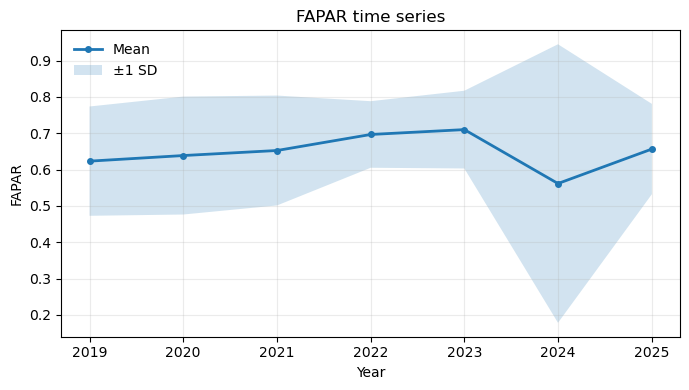

In [18]:
chart_data, chart_axis = chart_trait_time_series(
    trait="fapar",
    region=example_point,
    cfg=config,
    scale=20,
)

display(chart_data)
plt.show()